In [161]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns 


In [162]:
s = "bank-additional-full.csv"
df = pd.read_csv(s,sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [164]:
df.sample(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
37387,66.0,retired,unknown,basic.9y,no,yes,no,cellular,aug,wed,...,2.0,999.0,0.0,nonexistent,-2.9,92.201,-31.4,0.879,5076.2,no
26011,35.0,admin.,single,university.degree,no,yes,no,cellular,nov,wed,...,2.0,999.0,0.0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
23680,39.0,technician,divorced,professional.course,no,yes,no,cellular,aug,thu,...,2.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.962,5228.1,no
16733,56.0,retired,married,basic.4y,no,no,no,cellular,jul,thu,...,4.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
20097,29.0,admin.,married,university.degree,no,yes,no,cellular,aug,mon,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
33928,28.0,admin.,married,high.school,no,yes,no,cellular,may,wed,...,1.0,999.0,1.0,failure,-1.8,92.893,-46.2,1.281,5099.1,no
17813,26.0,self-employed,married,university.degree,no,yes,no,cellular,jul,tue,...,2.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,no
33625,39.0,admin.,married,basic.9y,unknown,yes,no,telephone,may,wed,...,6.0,999.0,0.0,nonexistent,-1.8,92.893,-46.2,1.281,5099.1,no
39001,73.0,retired,married,basic.4y,no,no,no,cellular,dec,mon,...,5.0,999.0,0.0,nonexistent,-3.0,92.713,-33.0,0.717,5023.5,no
36640,28.0,admin.,married,university.degree,no,yes,no,cellular,jun,thu,...,1.0,999.0,1.0,failure,-2.9,92.963,-40.8,1.260,5076.2,no


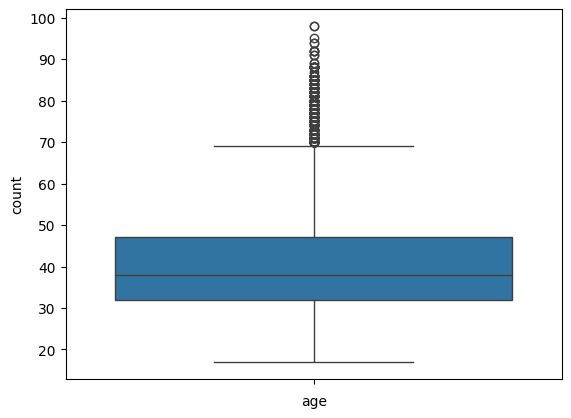

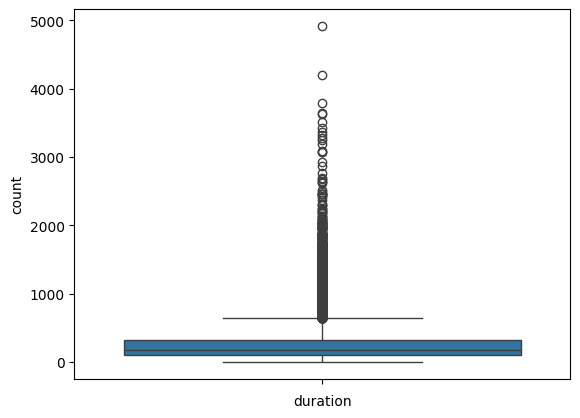

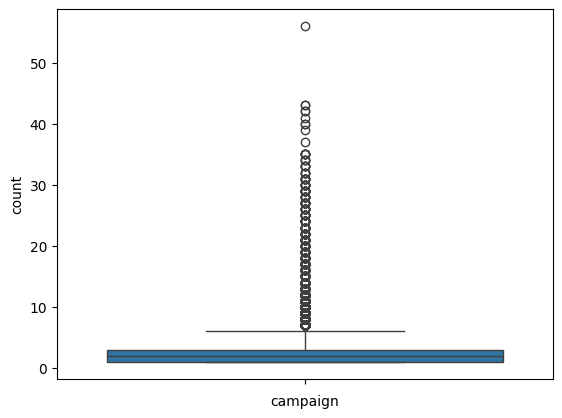

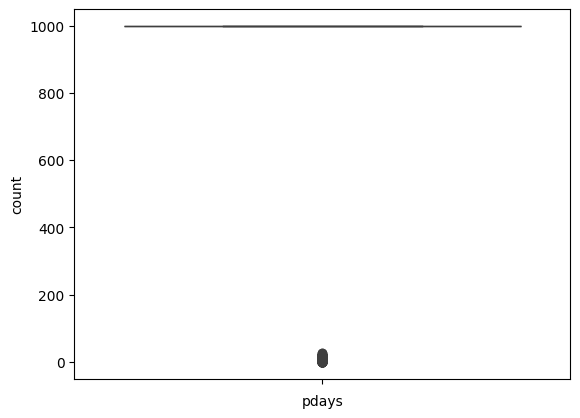

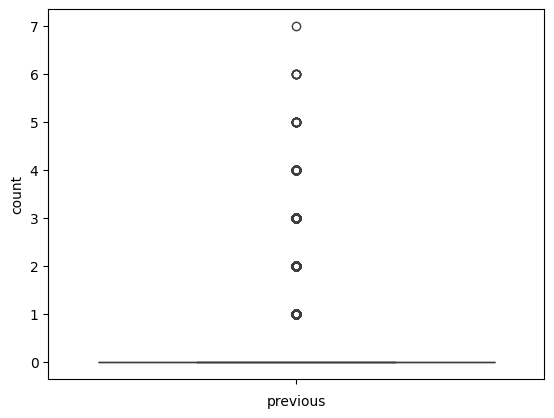

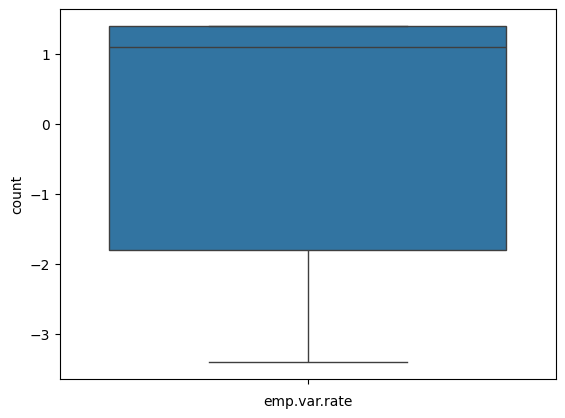

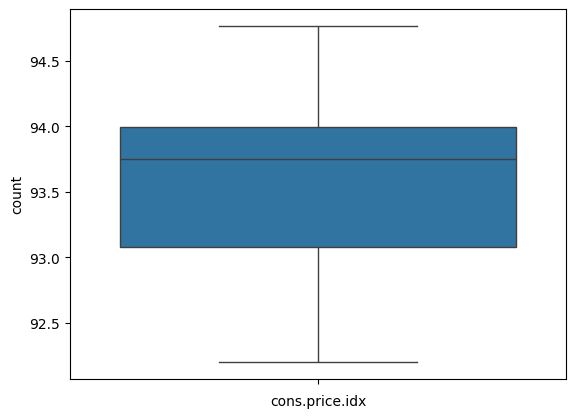

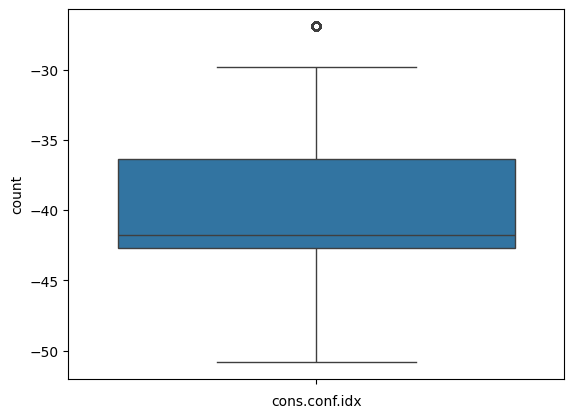

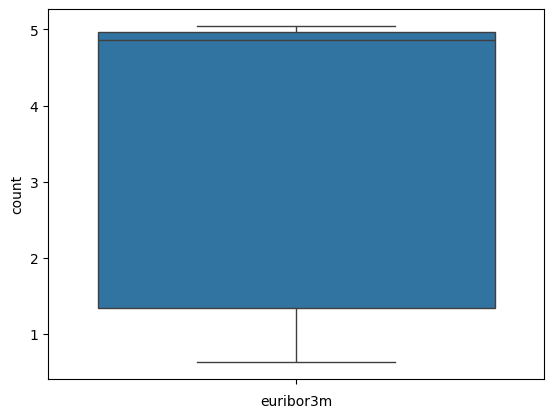

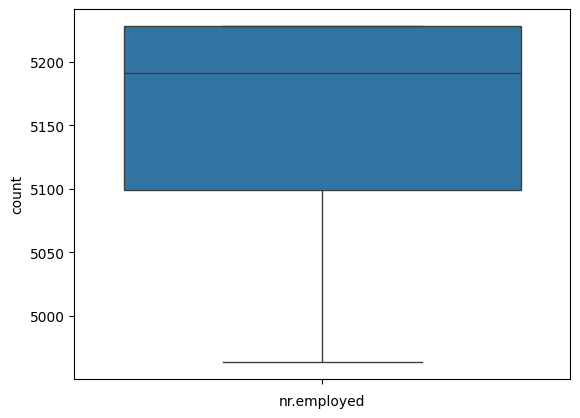

In [165]:
for col in df.columns:
    if (df[col].dtype == "float64" or df[col].dtypes =="int64"):
        sns.boxplot(df[col])
        plt.xlabel(col)
        plt.ylabel('count')
        plt.show()

In [166]:
q1 = df['age'].quantile(.25)
q3 = df['age'].quantile(.75)
iqr = q3 - q1
ll = q1 - iqr*1.5
ul = q3 + iqr*1.5
data = df[(df['age']>=ll) & (df['age']<=ul)]

q1 = data['duration'].quantile(.25)
q3 = data['duration'].quantile(.75)
iqr = q3 - q1
ll = q1 - iqr*1.5
ul = q3 + iqr*1.5
data = data[(data['duration']>=ll) & (data['duration']<=ul)]


q1 = data['campaign'].quantile(.25)
q3 = data['campaign'].quantile(.75)
iqr = q3 - q1
ll = q1 - iqr*1.5
ul = q3 + iqr*1.5
data = data[(data['campaign']>=ll) & (data['campaign']<=ul)]

q1 = data['cons.conf.idx'].quantile(.25)
q3 = data['cons.conf.idx'].quantile(.75)
iqr = q3 - q1
ll = q1 - iqr*1.5
ul = q3 + iqr*1.5
data = data[(data['cons.conf.idx']>=ll) & (data['cons.conf.idx']<=ul)]


In [167]:
data.y.value_counts()

y
no     32445
yes     2731
Name: count, dtype: int64

In [168]:
data_copy = data.copy()
data_copy.sample(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
39875,31.0,technician,married,professional.course,no,yes,no,telephone,jun,tue,...,1.0,999.0,0.0,nonexistent,-1.7,94.055,-39.8,0.723,4991.6,yes
39228,26.0,admin.,single,high.school,no,no,no,cellular,mar,tue,...,2.0,6.0,1.0,success,-1.8,93.369,-34.8,0.652,5008.7,yes
34444,24.0,services,single,high.school,no,no,no,cellular,may,thu,...,1.0,999.0,1.0,failure,-1.8,92.893,-46.2,1.266,5099.1,no
15853,44.0,blue-collar,married,basic.9y,unknown,no,no,cellular,jul,mon,...,1.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no
28030,39.0,services,married,high.school,no,no,no,cellular,apr,thu,...,2.0,999.0,2.0,failure,-1.8,93.075,-47.1,1.483,5099.1,no
10757,37.0,technician,married,high.school,no,yes,no,telephone,jun,tue,...,4.0,999.0,0.0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,no
30762,41.0,management,single,basic.9y,no,no,no,cellular,may,tue,...,1.0,999.0,1.0,failure,-1.8,92.893,-46.2,1.344,5099.1,no
21058,31.0,technician,married,professional.course,unknown,yes,yes,cellular,aug,thu,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no
12601,31.0,admin.,single,high.school,no,no,no,cellular,jul,mon,...,1.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no
5354,42.0,blue-collar,married,basic.6y,unknown,no,yes,telephone,may,fri,...,4.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


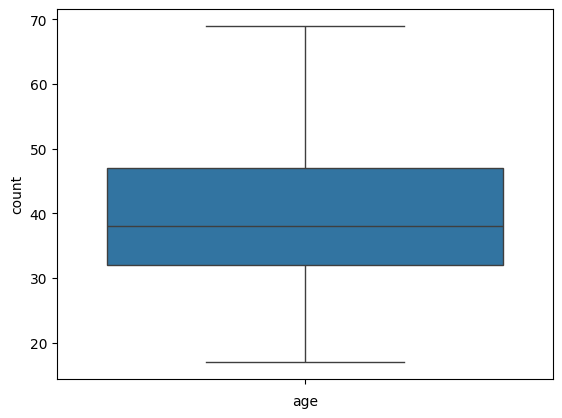

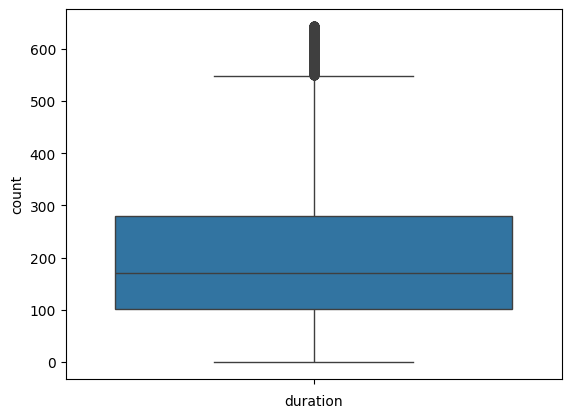

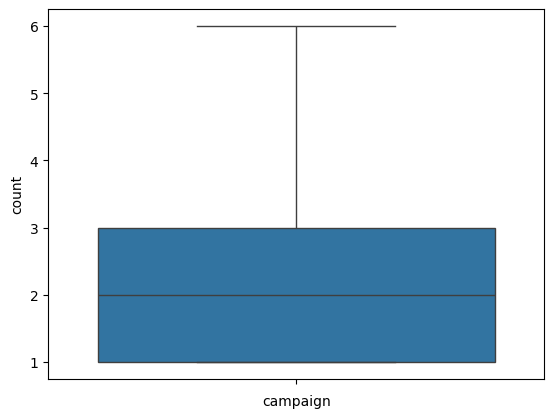

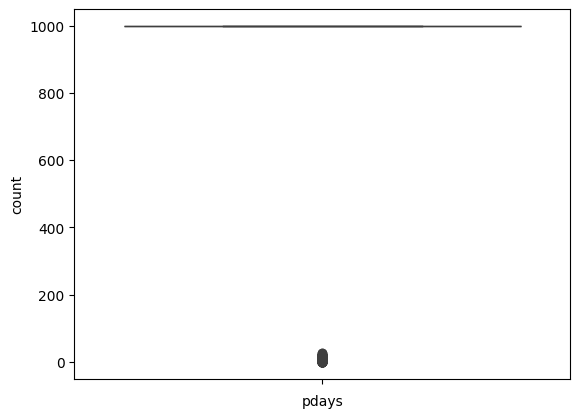

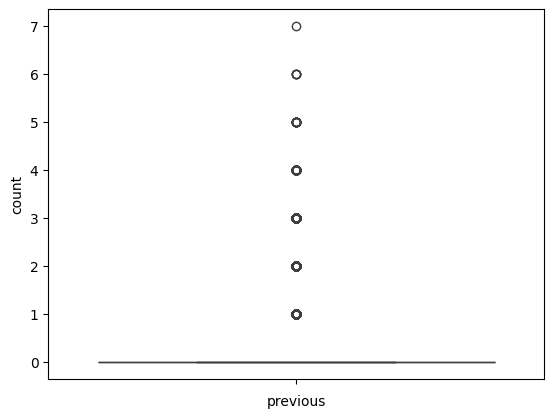

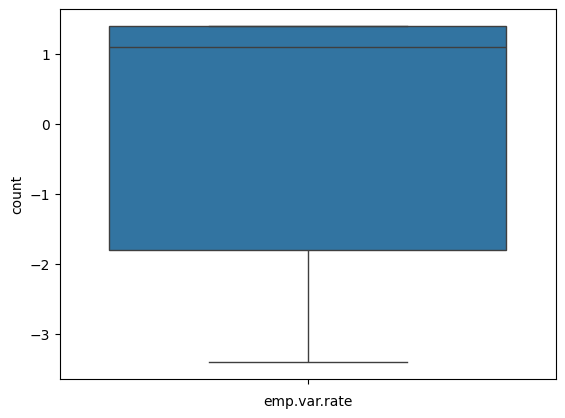

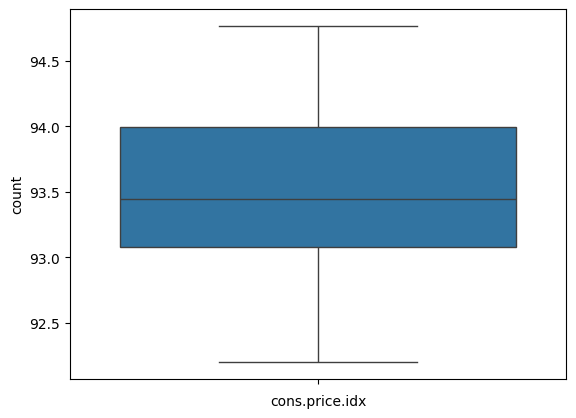

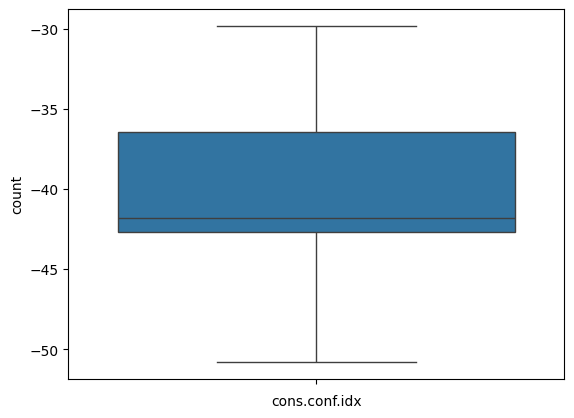

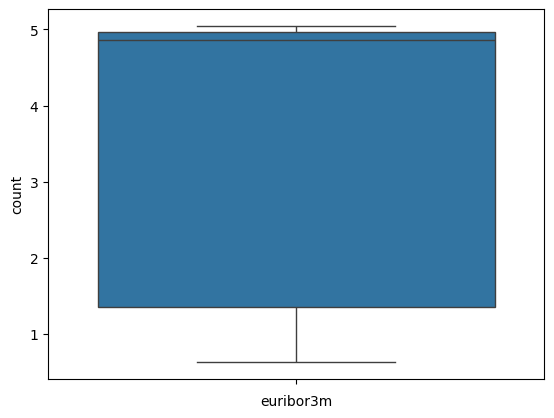

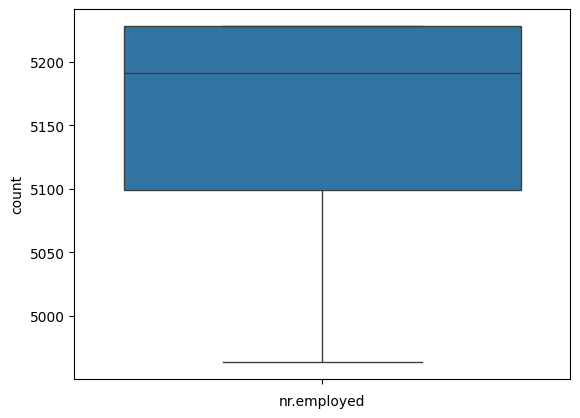

In [169]:
for col in data.columns:
    if (data[col].dtype == "float64" or data[col].dtypes =="int64"):
        sns.boxplot(data[col])
        plt.xlabel(col)
        plt.ylabel('count')
        plt.show()

In [170]:
data['y'] = data.y.map({'yes':1,'no':0})
data_copy['y'] = data_copy.y.map({'yes':1 ,'no':0})

In [171]:
data['age']=data['age'].astype('int')

In [172]:
bins = [0,50,100]
data['age'] = pd.cut(data['age'],bins)

In [173]:
data['age'] = data.age.astype(str)

In [174]:
data.sample(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
13117,"(50, 100]",services,married,high.school,no,no,no,telephone,jul,wed,...,1.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
28265,"(0, 50]",technician,single,professional.course,unknown,yes,no,cellular,apr,wed,...,1.0,999.0,0.0,nonexistent,-1.8,93.075,-47.1,1.445,5099.1,0
25336,"(0, 50]",management,married,university.degree,no,yes,yes,cellular,nov,tue,...,3.0,999.0,1.0,failure,-0.1,93.200,-42.0,4.153,5195.8,0
28051,"(0, 50]",blue-collar,single,basic.9y,no,no,no,telephone,apr,thu,...,2.0,999.0,0.0,nonexistent,-1.8,93.075,-47.1,1.483,5099.1,0
36857,"(0, 50]",admin.,married,university.degree,no,yes,no,cellular,jun,tue,...,1.0,999.0,0.0,nonexistent,-2.9,92.963,-40.8,1.252,5076.2,0
12997,"(0, 50]",blue-collar,married,basic.6y,no,no,no,telephone,jul,tue,...,3.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
9771,"(0, 50]",blue-collar,divorced,basic.9y,no,no,no,telephone,jun,mon,...,4.0,999.0,0.0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,0
31143,"(0, 50]",technician,married,professional.course,no,yes,no,cellular,may,wed,...,2.0,999.0,1.0,failure,-1.8,92.893,-46.2,1.334,5099.1,0
18855,"(50, 100]",blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,mon,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.970,5228.1,0
1247,"(0, 50]",technician,married,professional.course,no,no,no,telephone,may,thu,...,3.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0


In [175]:
data['age'].value_counts()/len(data['age'])

age
(0, 50]      0.836081
(50, 100]    0.163919
Name: count, dtype: float64

In [176]:
data.y.value_counts()

y
0    32445
1     2731
Name: count, dtype: int64

In [37]:
# # IV analysis 
# 0.02 to 0.1 Weak
# 0.1 to 0.3 Medium
# 0.3 to 0.5 Strong
# >0.5 suspicious

In [177]:
def cal_woe(dataset,feature,target):
    lst=[]
    for i in range(dataset[feature].nunique()):
        val = list(dataset[feature].unique())[i]
        lst.append({'Value': val,
                'All': dataset[dataset[feature]==val].count()[feature],
                'Good': dataset[(dataset[feature]==val) & (dataset[target]==1)].count()[feature],
                'Bad': dataset[(dataset[feature]==val) & (dataset[target]==0)].count()[feature]})
    all_list = pd.DataFrame(lst)
    all_list['Good%'] = all_list['Good'] / all_list['Good'].sum()
    all_list['Bad%'] = all_list['Bad'] / all_list['Bad'].sum()
    all_list['woe'] = np.log(all_list['Good%']/all_list['Bad%'])
    all_list = all_list.replace({'woe':{np.inf:0, -np.inf:0}})
    all_list['IV'] = (all_list['Good%'] - all_list['Bad%']) * all_list['woe']
    iv = all_list['IV'].sum()
    all_list = all_list.sort_values(by = 'woe')
    return all_list , iv



In [178]:
def calculate_woe_iv(dataset, feature, target):
    lst = []
    for i in range(dataset[feature].nunique()):
        val = list(dataset[feature].unique())[i]
        lst.append({
            'Value': val,
            'All': dataset[dataset[feature] == val].count()[feature],
            'Good': dataset[(dataset[feature] == val) & (dataset[target] == 1)].count()[feature],
            'Bad': dataset[(dataset[feature] == val) & (dataset[target] == 0)].count()[feature]
        })
        
    dset = pd.DataFrame(lst)
    dset['Distr_Good'] = dset['Good'] / dset['Good'].sum()
    dset['Distr_Bad'] = dset['Bad'] / dset['Bad'].sum()
    dset['WoE'] = np.log(dset['Distr_Good'] / dset['Distr_Bad'])
    dset = dset.replace({'WoE': {np.inf: 0, -np.inf: 0}})
    dset['IV'] = (dset['Distr_Good'] - dset['Distr_Bad']) * dset['WoE']
    iv = dset['IV'].sum()
    
    dset = dset.sort_values(by='WoE')
    
    return dset, iv

In [179]:
df_list = []
for col in data_copy.columns:
    if data[col].dtype == 'object':
        df, iv = calculate_woe_iv(data_copy, col, 'y')
        df_list.append({'feature': col, 'IV': iv})

df_new = pd.DataFrame(df_list)

e:\code\datascience\plot\.venv\ml\ML_Prog\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [180]:
df_new

,feature,IV
0,age,0.289641
1,job,0.285554
2,marital,0.068519
3,education,0.124747
4,default,0.282125
5,housing,0.003314
6,loan,0.000882
7,contact,0.387145
8,month,0.771319
9,day_of_week,0.007005


In [181]:
data = data.drop(columns=['age','marital','education','day_of_week','loan','housing'])
data_copy = data_copy.drop(columns=['age','marital','education','day_of_week','loan','housing'])

In [ ]:
# data_new = data.loc[:, ~data.columns.isin(['job', 'marital','default','poutcome','month','contact'])]

In [ ]:
# data_new.corr()

,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
duration,1.000000,-0.056893,-0.073909,0.045916,-0.051520,0.001185,-0.002758,-0.059965,-0.078609,0.268697
campaign,-0.056893,1.000000,0.042119,-0.057014,0.089151,0.066982,-0.005851,0.074389,0.084543,-0.054587
pdays,-0.073909,0.042119,1.000000,-0.574394,0.261045,0.064597,-0.072240,0.288819,0.368915,-0.379771
previous,0.045916,-0.057014,-0.574394,1.000000,-0.420139,-0.200582,-0.088658,-0.453300,-0.502056,0.264926
emp.var.rate,-0.051520,0.089151,0.261045,-0.420139,1.000000,0.767748,0.309296,0.972556,0.901906,-0.336070
cons.price.idx,0.001185,0.066982,0.064597,-0.200582,0.767748,1.000000,0.148943,0.681502,0.503828,-0.142035
cons.conf.idx,-0.002758,-0.005851,-0.072240,-0.088658,0.309296,0.148943,1.000000,0.373474,0.200454,0.041241
euribor3m,-0.059965,0.074389,0.288819,-0.453300,0.972556,0.681502,0.373474,1.000000,0.943611,-0.345697
nr.employed,-0.078609,0.084543,0.368915,-0.502056,0.901906,0.503828,0.200454,0.943611,1.000000,-0.404753
y,0.268697,-0.054587,-0.379771,0.264926,-0.336070,-0.142035,0.041241,-0.345697,-0.404753,1.000000


In [182]:
lst = []
for col in data.columns:
    if ((data[col].dtype == 'object') & (col !='y')):
        lst.append(col)     

In [183]:
lst     

['job', 'default', 'contact', 'month', 'poutcome']

In [184]:
# One Hat Encoding 
df_2 = pd.get_dummies(data[lst],drop_first=True,dtype=int)
df_2.shape

(35176, 25)

In [ ]:
# data_new.shape

(35176, 10)

In [185]:
data_combined = pd.concat([data,df_2],axis=1)
data_combined.shape
data_combined.sample(7)
data_combined.columns

Index(['job', 'default', 'contact', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'default_unknown', 'default_yes',
       'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_nonexistent', 'poutcome_success'],
      dtype='object')

In [186]:
data_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35176 entries, 0 to 41186
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job                   35176 non-null  object 
 1   default               35176 non-null  object 
 2   contact               35176 non-null  object 
 3   month                 35176 non-null  object 
 4   duration              35176 non-null  float64
 5   campaign              35176 non-null  float64
 6   pdays                 35176 non-null  float64
 7   previous              35176 non-null  float64
 8   poutcome              35176 non-null  object 
 9   emp.var.rate          35176 non-null  float64
 10  cons.price.idx        35176 non-null  float64
 11  cons.conf.idx         35176 non-null  float64
 12  euribor3m             35176 non-null  float64
 13  nr.employed           35176 non-null  float64
 14  y                     35176 non-null  int64  
 15  job_blue-collar       35

Label Encoder

In [187]:
from sklearn.preprocessing import LabelEncoder
labelencode = LabelEncoder()
for i in lst:
    data_copy[i] = labelencode.fit_transform(data_copy[i])

In [190]:
data_copy.sample(10)

,job,default,contact,month,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1823,0,0,1,6,137.0,2.0,999.0,0.0,1,1.1,93.994,-36.4,4.855,5191.0,0
5349,1,1,1,6,353.0,2.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
23900,0,0,0,1,186.0,3.0,999.0,0.0,1,1.4,93.444,-36.1,4.963,5228.1,0
28506,1,0,0,0,107.0,3.0,999.0,0.0,1,-1.8,93.075,-47.1,1.423,5099.1,1
992,1,0,1,6,311.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.856,5191.0,0
1863,1,1,1,6,455.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.855,5191.0,0
35659,1,1,0,6,316.0,1.0,999.0,0.0,1,-1.8,92.893,-46.2,1.244,5099.1,0
17661,5,1,0,3,174.0,6.0,999.0,0.0,1,1.4,93.918,-42.7,4.962,5228.1,0
3701,0,0,1,6,161.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.859,5191.0,0
23827,0,0,0,1,214.0,4.0,999.0,0.0,1,1.4,93.444,-36.1,4.963,5228.1,0


In [191]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [192]:
# Varience Influence Factor
lst_vf = []
for col in data_copy.columns:
    if ((data_copy[col].dtype !='object') & (col !='y')):
        lst_vf.append(col)

x = data_copy[lst_vf]
vif = pd.DataFrame()
vif['feature'] = x.columns
vif['vif'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]


In [203]:
vif

,feature,vif
0,job,2.064439
1,default,1.328178
2,contact,2.907079
3,month,6.631271
4,duration,3.225472
5,campaign,3.604447
6,pdays,174.893405
7,previous,6.068490
8,poutcome,34.924956
9,emp.var.rate,37.456509


In [202]:
data_copy = data_copy.drop(columns=['nr.employed','pdays','cons.price.idx','euribor3m','cons.conf.idx'])

KeyError: "['nr.employed', 'pdays', 'cons.price.idx', 'euribor3m', 'cons.conf.idx'] not found in axis"

In [204]:
data_copy

,job,default,contact,month,duration,campaign,previous,poutcome,emp.var.rate,y
0,3,0,1,6,261.0,1.0,0.0,1,1.1,0
1,7,1,1,6,149.0,1.0,0.0,1,1.1,0
2,7,0,1,6,226.0,1.0,0.0,1,1.1,0
3,0,0,1,6,151.0,1.0,0.0,1,1.1,0
4,7,0,1,6,307.0,1.0,0.0,1,1.1,0
...,...,...,...,...,...,...,...,...,...,...
41181,0,0,0,7,281.0,1.0,0.0,1,-1.1,1
41182,10,0,0,7,112.0,1.0,1.0,2,-1.1,0
41184,1,0,0,7,383.0,1.0,0.0,1,-1.1,0
41185,5,0,0,7,189.0,2.0,0.0,1,-1.1,0


In [230]:
from sklearn.model_selection._split import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.75,random_state=1)
x=data_copy.loc[:,:data_copy.columns[-2]]
y = data_copy['y']
y

0        0
1        0
2        0
3        0
4        0
        ..
41181    1
41182    0
41184    0
41185    0
41186    1
Name: y, Length: 35176, dtype: int64

In [231]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [232]:
clf.fit(x_train, y_train)

e:\code\datascience\plot\.venv\ml\ML_Prog\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [236]:
pred

array([0, 0, 0, ..., 0, 0, 0], shape=(26382,))

In [235]:
pred = clf.predict(x_test)
pred_table = pd.DataFrame()
pred_table['y_test'] = y_test
pred_table['y_pred'] = pred
pred_table

,y_test,y_pred
30623,0,0
6456,0,0
6191,0,0
19455,0,0
30966,0,0
...,...,...
21629,0,0
1517,0,0
34637,0,0
14977,0,0


In [238]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.9318095671291031

In [240]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,pred)

In [241]:
cm

array([[23918,   418],
       [ 1381,   665]])